# **Quality Alpha: Free Cash Flow Yield under Debt Constraints**
This study evaluates the interaction between Free Cash Flow Yield ($\text{FCF}/\text{EV}$) and strict Sharia debt-to-market-cap thresholds ($<30\%$). By filtering out highly leveraged entities, the universe isolatively targets capital-efficient, highly generative businesses. This paper backtests whether removing financial leverage naturally enhances the persistence of the Quality factor premium across market cycles.

## Setup

Install dependencies and configure the backtest window.

`FAST_MODE = False` uses the full S&P 500 (slower: SEC / yfinance calls). Keep it `True` only for a smoke test. Performance stats start on the first day the strategy actually holds stocks, not on `START`.

In [14]:
%pip install -q halalquant yfinance matplotlib requests

import warnings
from datetime import date
from io import StringIO

import requests
from IPython.display import display

import halalquant as hq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from halalquant.screening._aaoifi import AAOIFIScreener
from halalquant.screening._sector_filter import SectorFilter
from halalquant.providers._yfinance import YFinanceProvider

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Backtest configuration ---
START = "2019-01-01"
END = "2024-12-31"
TOP_QUANTILE = 0.20              # hold the top fifth of Halal-compliant names
MIN_HOLDINGS = 5                 # skip a rebalance if the screen is too thin
REBALANCE_FREQ = "ME"            # "ME" = monthly, "QE" = quarterly
DEBT_THRESHOLD = 0.30            # AAOIFI debt / 24m market cap limit
FILING_LAG_DAYS = 90             # conservative PIT lag for yfinance cashflow dates
FAST_MODE = False                # True → 60 names (smoke test); False → full S&P 500
RISK_FREE_RATE = 0.02            # annualized, for Sharpe ratio
VOL_LOOKBACK = 252               # trailing trading days for the robustness vol cut
DROP_HIGH_VOL_QUANTILE = 0.20    # robustness: drop jumpiest fifth of FCF/EV picks
COST_BPS = 10                    # one-way trading cost assumption for the friction table

BENCHMARKS = {
    "S&P 500": "SPY",
    "Halal (SPUS)": "SPUS",      # SP Funds S&P 500 Sharia Industry Exclusions ETF
}

print(f"halalquant v{hq.__version__}")


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
halalquant v0.1.0


## Step 1 — Start with a universe of stocks

We use **S&P 500 constituents** as the broad US equity universe, then pre-filter excluded business activities (banks, alcohol, gambling, etc.) using `halalquant`'s sector screen.

In [15]:
FALLBACK_SP500 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "BRK-B", "LLY", "AVGO", "JPM",
    "UNH", "XOM", "V", "MA", "PG", "COST", "HD", "JNJ", "ABBV", "NFLX",
    "CRM", "MRK", "AMD", "PEP", "KO", "TMO", "ADBE", "WMT", "CSCO", "ACN",
    "MCD", "LIN", "ABT", "DHR", "INTC", "CMCSA", "TXN", "QCOM", "INTU", "AMAT",
    "DIS", "IBM", "GE", "CAT", "NOW", "VZ", "AMGN", "PFE", "ISRG", "GS",
]


def load_sp500_tickers() -> list[str]:
    """Fetch current S&P 500 symbols from Wikipedia (with offline fallback)."""
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "MontereyFinanceResearch/1.0 (halal-quant-notebook)"}
    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        table = pd.read_html(StringIO(response.text), attrs={"id": "constituents"})[0]
        return (
            table["Symbol"]
            .astype(str)
            .str.replace(".", "-", regex=False)
            .tolist()
        )
    except Exception as exc:
        print(f"Could not fetch S&P 500 list ({exc}); using fallback basket.")
        return FALLBACK_SP500.copy()


def apply_sector_screen(tickers: list[str]) -> tuple[list[str], pd.DataFrame, dict[str, str]]:
    """Remove non-compliant sectors before financial ratio screens run."""
    provider = YFinanceProvider()
    sector_map = provider.get_sector_map(tickers)
    sector_filter = SectorFilter()
    kept = sector_filter.filter_symbols(tickers, sector_map=sector_map)
    audit = pd.DataFrame(sector_filter.audit_log)
    return kept, audit, sector_map


raw_universe = load_sp500_tickers()
if FAST_MODE:
    raw_universe = raw_universe[:60]
    print("FAST_MODE is on — smoke-test universe only. Set FAST_MODE = False for the paper.\n")

eligible_universe, sector_audit, activity_labels = apply_sector_screen(raw_universe)

print(f"Raw universe:      {len(raw_universe)} tickers")
print(f"After sector screen: {len(eligible_universe)} tickers")
print(f"Removed by sector:   {len(raw_universe) - len(eligible_universe)}")

sector_audit.head(10)

Raw universe:      503 tickers
After sector screen: 439 tickers
Removed by sector:   64


,symbol,sector,reason
0,AFL,conventional insurance,excluded business activity
1,ALL,conventional insurance,excluded business activity
2,MO,tobacco,excluded business activity
3,AXP,conventional banking,excluded business activity
4,AIG,conventional insurance,excluded business activity
5,AON,conventional insurance,excluded business activity
6,ACGL,conventional insurance,excluded business activity
7,AJG,conventional insurance,excluded business activity
8,AIZ,conventional insurance,excluded business activity
9,AXON,defense,excluded business activity


## Steps 2–6 — Filter, score, rank, select, rebalance

Pipeline at each rebalance date (point-in-time, no look-ahead):

1. **FILTER** — AAOIFI financial screens: debt, cash, and receivables ratios vs 24-month average market cap
2. **SCORE** — `FCF Yield = Free Cash Flow / Enterprise Value`, where `EV = Market Cap + Debt − Cash`
3. **RANK** — sort descending by FCF/EV
4. **SELECT** — equal-weight the top fifth (`TOP_QUANTILE`) of names that passed the screen. Need at least `MIN_HOLDINGS` names or that month is skipped.
5. **REBALANCE** — repeat every month (`REBALANCE_FREQ = "ME"`)

Performance is scored only after the first month that has real holdings. Days before that are treated as "not started yet," not as a 0% return. The S&P 500 and Halal ETF are scored over that same live window so the comparison is fair.

A separate robustness run uses the same FCF/EV ranks, then drops the jumpiest fifth of those picks (`DROP_HIGH_VOL_QUANTILE`). That is a check, not a second strategy.

In [16]:
def build_fcf_history(symbols: list[str], filing_lag_days: int = FILING_LAG_DAYS) -> pd.DataFrame:
    """Annual free cash flow history with a conservative public filing lag."""
    rows: list[dict] = []

    n_symbols = len(symbols)
    for i, symbol in enumerate(symbols, 1):
        if i == 1 or i % 50 == 0 or i == n_symbols:
            print(f"  FCF history {i}/{n_symbols}", flush=True)
        try:
            cashflow = yf.Ticker(symbol).cashflow
        except Exception:
            continue
        if cashflow is None or cashflow.empty:
            continue

        if "Free Cash Flow" in cashflow.index:
            fcf_label = "Free Cash Flow"
        elif "Operating Cash Flow" in cashflow.index:
            fcf_label = "Operating Cash Flow"
            capex = cashflow.loc["Capital Expenditure"] if "Capital Expenditure" in cashflow.index else None
        else:
            continue

        for period_end in cashflow.columns:
            if fcf_label == "Free Cash Flow":
                fcf = cashflow.at[fcf_label, period_end]
            else:
                ocf = cashflow.at[fcf_label, period_end]
                cap = capex.at[period_end] if capex is not None else np.nan
                fcf = ocf + cap if pd.notna(cap) else ocf  # CapEx is usually negative

            if pd.isna(fcf):
                continue

            report_ts = pd.Timestamp(period_end).normalize()
            filed_ts = report_ts + pd.Timedelta(days=filing_lag_days)
            rows.append(
                {
                    "symbol": symbol,
                    "report_date": report_ts.date(),
                    "filed_date": filed_ts.date(),
                    "fcf": float(fcf),
                }
            )

    return pd.DataFrame(rows)


def attach_latest_fcf(metrics: pd.DataFrame, fcf_history: pd.DataFrame) -> pd.DataFrame:
    """Join the latest FCF filing known on each metrics snapshot date."""
    if metrics.empty or fcf_history.empty:
        out = metrics.copy()
        out["fcf"] = np.nan
        return out

    fcf = fcf_history.copy()
    fcf["filed_date"] = pd.to_datetime(fcf["filed_date"])
    fcf["report_date"] = pd.to_datetime(fcf["report_date"])

    pieces: list[pd.DataFrame] = []
    for as_of, snap in metrics.groupby("as_of", sort=True):
        as_of_ts = pd.Timestamp(as_of)
        snap = snap.copy()
        fcf_values: list[float | np.nan] = []

        for _, row in snap.iterrows():
            known = fcf[
                (fcf["symbol"] == row["symbol"]) & (fcf["filed_date"] <= as_of_ts)
            ]
            if known.empty:
                fcf_values.append(np.nan)
            else:
                fcf_values.append(float(known.sort_values("report_date").iloc[-1]["fcf"]))

        snap["fcf"] = fcf_values
        pieces.append(snap)

    return pd.concat(pieces, ignore_index=True)


def score_fcf_ev(panel: pd.DataFrame) -> pd.DataFrame:
    """Compute Enterprise Value and FCF/EV yield."""
    out = panel.copy()
    out["enterprise_value"] = (
        pd.to_numeric(out["market_cap"], errors="coerce")
        + pd.to_numeric(out["total_debt"], errors="coerce").fillna(0)
        - pd.to_numeric(out["cash_and_equiv"], errors="coerce").fillna(0)
    )
    out["fcf_yield"] = out["fcf"] / out["enterprise_value"]
    return out


def trailing_volatility(
    price_panel: pd.DataFrame,
    as_of: date,
    lookback: int = VOL_LOOKBACK,
) -> pd.Series:
    """Annualized trailing volatility for each symbol as of a rebalance date."""
    window = price_panel.loc[: pd.Timestamp(as_of)].tail(lookback + 1)
    if len(window) < max(60, lookback // 2):
        return pd.Series(dtype=float)
    return window.pct_change(fill_method=None).std() * np.sqrt(252)


def select_top_fcf_ev(
    panel: pd.DataFrame,
    as_of: date,
    top_quantile: float = TOP_QUANTILE,
    min_holdings: int = MIN_HOLDINGS,
    screener: AAOIFIScreener | None = None,
    vol_by_symbol: pd.Series | None = None,
    drop_high_vol_quantile: float | None = None,
) -> pd.DataFrame:
    """FILTER → SCORE → RANK → SELECT for one rebalance date."""
    empty_cols = ["symbol", "fcf_yield", "enterprise_value", "debt_ratio", "cash_ratio", "receivables_ratio"]
    screener = screener or AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)

    snap = panel[panel["as_of"] == as_of].copy()
    if snap.empty:
        return pd.DataFrame(columns=empty_cols)

    screened = screener.evaluate_compliance(snap)
    snap = snap.drop(columns=[c for c in ("debt_ratio", "cash_ratio", "receivables_ratio") if c in snap.columns])
    passed = snap.merge(screened, on="symbol", how="inner")
    passed = passed[passed["is_compliant"].fillna(False)].copy()
    passed = score_fcf_ev(passed)

    passed = passed[
        passed["enterprise_value"].notna()
        & (passed["enterprise_value"] > 0)
        & passed["fcf"].notna()
        & passed["fcf_yield"].notna()
        & np.isfinite(passed["fcf_yield"])
    ]

    if len(passed) < min_holdings:
        return pd.DataFrame(columns=empty_cols)

    n_hold = min(len(passed), max(min_holdings, int(np.ceil(len(passed) * top_quantile))))
    selected = passed.nlargest(n_hold, "fcf_yield").copy()

    if (
        drop_high_vol_quantile
        and vol_by_symbol is not None
        and not vol_by_symbol.empty
        and len(selected) > min_holdings
    ):
        selected["vol"] = selected["symbol"].map(vol_by_symbol)
        vol_ok = selected["vol"].dropna()
        if len(vol_ok) >= min_holdings:
            cutoff = vol_ok.quantile(1 - drop_high_vol_quantile)
            filtered = selected[selected["vol"].isna() | (selected["vol"] <= cutoff)]
            if len(filtered) >= 1:
                selected = filtered

    keep = [c for c in empty_cols + ["vol"] if c in selected.columns]
    return selected[keep]


def run_fcf_ev_backtest(
    metrics: pd.DataFrame,
    fcf_history: pd.DataFrame,
    prices: pd.DataFrame,
    top_quantile: float = TOP_QUANTILE,
    min_holdings: int = MIN_HOLDINGS,
    drop_high_vol_quantile: float | None = None,
    vol_lookback: int = VOL_LOOKBACK,
) -> tuple[pd.DataFrame, pd.DataFrame, list[date]]:
    """Equal-weight FCF/EV quintile book with point-in-time fundamentals.

    Days before the first real holdings are missing (not 0%). After going live,
    an empty book is treated as cash (0%).
    """
    panel = attach_latest_fcf(metrics, fcf_history)
    screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)

    price_panel = (
        prices.pivot(index="date", columns="symbol", values="adj_close")
        .sort_index()
        .ffill()
    )
    daily_returns = price_panel.pct_change(fill_method=None)

    rebalance_dates = sorted(panel["as_of"].dropna().unique())
    rebalance_dates = [pd.Timestamp(d).date() for d in rebalance_dates]

    selections: dict[date, list[str]] = {}
    selection_log: list[pd.DataFrame] = []

    for as_of in rebalance_dates:
        vol_by_symbol = (
            trailing_volatility(price_panel, as_of, lookback=vol_lookback)
            if drop_high_vol_quantile
            else None
        )
        picks = select_top_fcf_ev(
            panel,
            as_of=as_of,
            top_quantile=top_quantile,
            min_holdings=min_holdings,
            screener=screener,
            vol_by_symbol=vol_by_symbol,
            drop_high_vol_quantile=drop_high_vol_quantile,
        )
        selections[as_of] = picks["symbol"].tolist()
        if not picks.empty:
            picks = picks.assign(as_of=as_of)
            selection_log.append(picks)

    selection_df = (
        pd.concat(selection_log, ignore_index=True)
        if selection_log
        else pd.DataFrame(columns=["symbol", "fcf_yield", "as_of"])
    )

    port_rows: list[dict] = []
    active: list[str] = []
    last_rebalance: date | None = None
    live = False

    for dt in daily_returns.index:
        prior = [d for d in rebalance_dates if pd.Timestamp(d) <= dt]
        if prior and prior[-1] != last_rebalance:
            active = selections.get(prior[-1], [])
            last_rebalance = prior[-1]
            if active:
                live = True

        if not live:
            port_rows.append({"date": dt.date(), "return": np.nan})
            continue

        held = [s for s in active if s in daily_returns.columns]
        if not held:
            port_rows.append({"date": dt.date(), "return": 0.0})
            continue

        day_ret = daily_returns.loc[dt, held].mean(skipna=True)
        port_rows.append({"date": dt.date(), "return": 0.0 if pd.isna(day_ret) else float(day_ret)})

    port_returns = pd.DataFrame(port_rows)
    port_returns["date"] = pd.to_datetime(port_returns["date"])
    return port_returns, selection_df, rebalance_dates


def calc_performance_stats(daily_returns: pd.Series, label: str, rf: float = RISK_FREE_RATE) -> dict:
    """CAGR, volatility, Sharpe, Sortino, max drawdown, Calmar."""
    r = daily_returns.dropna()
    if r.empty:
        return {"Strategy": label, "CAGR": np.nan, "Volatility": np.nan, "Sharpe": np.nan,
                "Sortino": np.nan, "Max Drawdown": np.nan, "Calmar": np.nan}

    equity = (1 + r).cumprod()
    years = len(r) / 252
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = r.std() * np.sqrt(252)
    excess = r - rf / 252
    sharpe = excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else np.nan
    downside = r[r < 0]
    sortino = (r.mean() - rf / 252) / downside.std() * np.sqrt(252) if len(downside) else np.nan
    dd = equity / equity.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    return {
        "Strategy": label,
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
    }

In [18]:
# Prefetch price history, point-in-time fundamentals, and FCF history
print("Fetching FCF history …")
fcf_history = build_fcf_history(eligible_universe)
print(f"  {fcf_history['symbol'].nunique()} symbols with FCF data")

print("Fetching point-in-time AAOIFI metrics …")
metrics = hq.get_financial_metrics(
    eligible_universe,
    start=START,
    end=END,
    freq=REBALANCE_FREQ,
)
print(f"  {metrics.shape[0]} snapshot rows")

all_symbols = sorted(set(eligible_universe) | set(BENCHMARKS.values()))
print("Downloading price history …")
prices = hq.download(all_symbols, start=START, end=END)
prices["date"] = pd.to_datetime(prices["date"])
print(f"  {prices['symbol'].nunique()} symbols, {prices['date'].nunique()} trading days")

metrics.head()

Fetching FCF history …
  FCF history 1/439
  FCF history 50/439
  FCF history 100/439
  FCF history 150/439
  FCF history 200/439
  FCF history 250/439
  FCF history 300/439
  FCF history 350/439
  FCF history 400/439
  FCF history 439/439
  438 symbols with FCF data
Fetching point-in-time AAOIFI metrics …


$FDXF: possibly delisted; no price data found  (1d 2019-08-18 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1566100800, endDate = 1735621200")
$Q: possibly delisted; no price data found  (1d 2019-08-18 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1566100800, endDate = 1735621200")
$SNDK: possibly delisted; no price data found  (1d 2019-08-18 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1566100800, endDate = 1735621200")

3 Failed downloads:
['FDXF', 'Q', 'SNDK']: possibly delisted; no price data found  (1d 2019-08-18 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1566100800, endDate = 1735621200")


  10880 snapshot rows


$FDXF: possibly delisted; no price data found  (1d 2019-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735621200")
$Q: possibly delisted; no price data found  (1d 2019-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735621200")
$SNDK: possibly delisted; no price data found  (1d 2019-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735621200")

3 Failed downloads:
['FDXF', 'Q', 'SNDK']: possibly delisted; no price data found  (1d 2019-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1546318800, endDate = 1735621200")


  441 symbols, 1509 trading days


,symbol,as_of,report_date,filed_date,total_debt,cash_and_equiv,interest_bearing_securities,receivables,liquid_assets,market_cap,market_cap_24m,debt_ratio,cash_ratio,receivables_ratio,total_revenue,non_compliant_income,impure_ratio
0,COST,2021-11-30,2021-08-31,2021-11-29,799000000.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
1,MU,2021-11-30,2021-08-31,2021-11-29,1000000.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
2,COST,2021-12-31,2021-08-31,2021-11-29,799000000.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
3,MU,2021-12-31,2021-08-31,2021-11-29,1000000.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
4,FFIV,2021-12-31,2021-09-30,2021-12-29,369047000.0,0.0,329630000.0,0.0,329630000.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN


In [ ]:
# Run the FCF/EV strategy backtest
strategy_returns, selections, rebalance_dates = run_fcf_ev_backtest(
    metrics=metrics,
    fcf_history=fcf_history,
    prices=prices[prices["symbol"].isin(eligible_universe)],
    top_quantile=TOP_QUANTILE,
    min_holdings=MIN_HOLDINGS,
)

robust_returns, robust_selections, _ = run_fcf_ev_backtest(
    metrics=metrics,
    fcf_history=fcf_history,
    prices=prices[prices["symbol"].isin(eligible_universe)],
    top_quantile=TOP_QUANTILE,
    min_holdings=MIN_HOLDINGS,
    drop_high_vol_quantile=DROP_HIGH_VOL_QUANTILE,
    vol_lookback=VOL_LOOKBACK,
)

live_dates = strategy_returns.loc[strategy_returns["return"].notna(), "date"]
holdings_per_date = selections.groupby("as_of")["symbol"].nunique() if not selections.empty else pd.Series(dtype=int)

print(f"Rebalance dates with data: {len(rebalance_dates)}")
print(f"First metrics date:        {rebalance_dates[0] if rebalance_dates else 'n/a'}")
print(f"First invested date:       {live_dates.min().date() if not live_dates.empty else 'n/a'}")
print(f"Last rebalance:            {rebalance_dates[-1] if rebalance_dates else 'n/a'}")
if not holdings_per_date.empty:
    print(
        "Holdings per live rebalance: "
        f"min={int(holdings_per_date.min())}  "
        f"median={holdings_per_date.median():.0f}  "
        f"max={int(holdings_per_date.max())}"
    )

print(f"\nLatest holdings ({rebalance_dates[-1]}):")
latest = selections[selections["as_of"] == rebalance_dates[-1]].copy()
if not latest.empty:
    latest["fcf_yield"] = latest["fcf_yield"].map(lambda x: f"{x:.2%}")
    display(latest.reset_index(drop=True))
else:
    print("  (no compliant picks on last rebalance date)")

Rebalance dates with data: 36
First metrics date:        2022-01-31
First invested date:       2023-01-03
Last rebalance:            2024-12-31
Holdings per live rebalance: min=5  median=6  max=7

Latest holdings (2024-12-31):


,symbol,fcf_yield,enterprise_value,debt_ratio,cash_ratio,receivables_ratio,as_of
0,ADM,8.75%,3.391391e+10,0.273798,0.039033,0.189799,2024-12-31
1,ABBV,6.17%,3.577298e+11,0.206754,0.044620,0.083457,2024-12-31
2,AOS,6.07%,9.850108e+09,0.013932,0.032622,0.086125,2024-12-31
3,AMAT,5.58%,1.361791e+11,0.043761,0.050107,0.087784,2024-12-31
4,ABNB,4.88%,7.952478e+10,0.027084,0.118386,0.120795,2024-12-31
5,APTV,4.52%,2.191970e+10,0.283391,0.068478,0.216541,2024-12-31


## Step 7 — Measure performance vs benchmarks

Compare the FCF/EV strategy against **SPY** (S&P 500) and **SPUS** (Halal-screened S&P 500 ETF proxy).

All numbers use the **live window only**: from the first day the strategy holds stocks through `END`. The extra row, **FCF/EV (drop high vol)**, is the same ranking with the jumpiest fifth of picks removed. It is a robustness check, not the main result.

Later cells add the rest of the white-paper evidence: drawdowns, calendar-year returns, FCF/EV quintile spreads, alpha/beta/sector mix, turnover, trading costs, and purification drag.

Live window (main strategy): 2023-01-03 → 2024-12-30  (501 trading days)
Live window (drop high vol): 2023-01-03 → 2024-12-30  (501 trading days)


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Strategy,,,,,,
FCF/EV Strategy,25.59%,16.52%,1.34,2.05,-14.15%,1.81
FCF/EV (drop high vol),11.74%,16.04%,0.65,0.99,-13.04%,0.90
S&P 500,25.93%,12.82%,1.71,2.50,-9.97%,2.60
Halal (SPUS),31.11%,15.07%,1.74,2.58,-11.46%,2.71


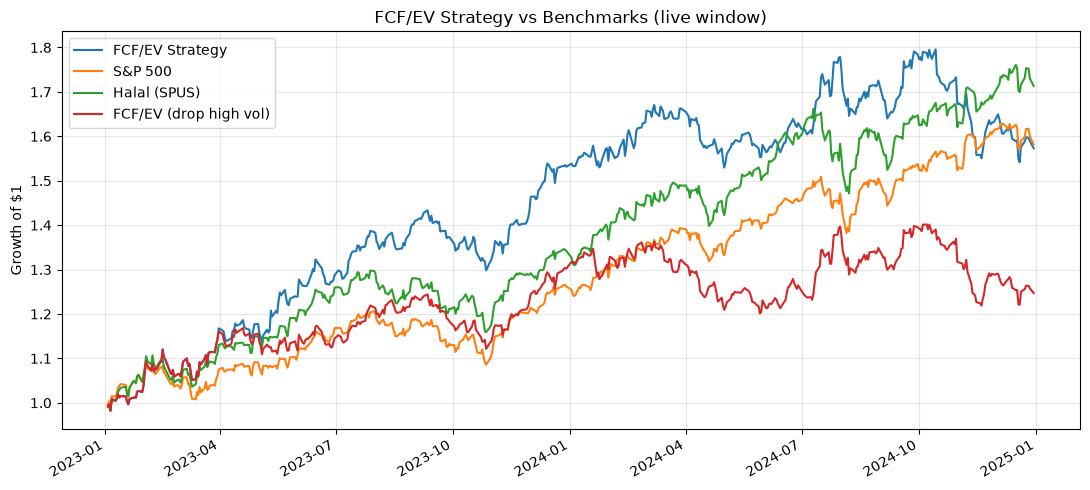

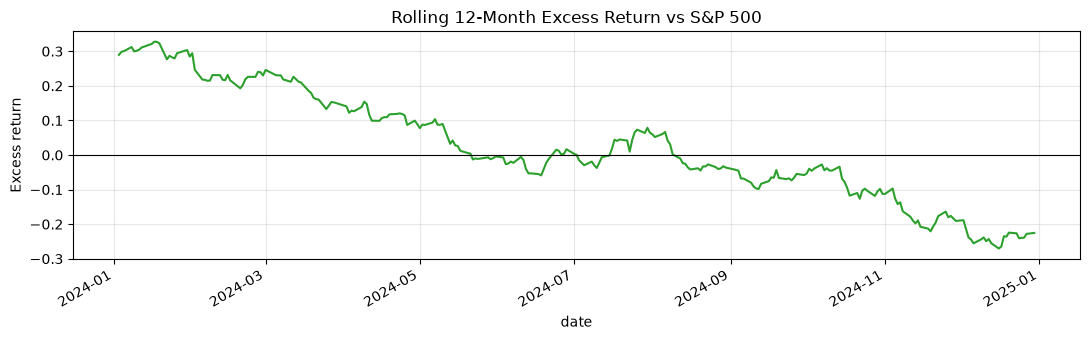

In [ ]:
def benchmark_returns(ticker: str) -> pd.Series:
    px = prices[prices["symbol"] == ticker].copy()
    px = px.sort_values("date").set_index("date")["adj_close"]
    return px.pct_change(fill_method=None).dropna()


def align_to_live(strategy: pd.Series, benches: dict[str, pd.Series]) -> pd.DataFrame:
    """Keep only days the strategy is live, and the same days for every benchmark."""
    panel = pd.DataFrame({"strategy": strategy})
    for name, series in benches.items():
        panel[name] = series
    return panel.dropna(how="any")


bench_series = {name: benchmark_returns(ticker) for name, ticker in BENCHMARKS.items()}
strategy_s = strategy_returns.set_index("date")["return"].rename("FCF/EV Strategy")
robust_s = robust_returns.set_index("date")["return"].rename("FCF/EV (drop high vol)")

main_panel = align_to_live(strategy_s, bench_series).rename(columns={"strategy": "FCF/EV Strategy"})
robust_panel = align_to_live(robust_s, bench_series).rename(columns={"strategy": "FCF/EV (drop high vol)"})

if main_panel.empty:
    raise RuntimeError("No overlapping live days between the strategy and benchmarks.")

print(
    "Live window (main strategy): "
    f"{main_panel.index.min().date()} → {main_panel.index.max().date()}  "
    f"({len(main_panel)} trading days)"
)
if not robust_panel.empty:
    print(
        "Live window (drop high vol): "
        f"{robust_panel.index.min().date()} → {robust_panel.index.max().date()}  "
        f"({len(robust_panel)} trading days)"
    )

rows = [calc_performance_stats(main_panel["FCF/EV Strategy"], "FCF/EV Strategy")]
if not robust_panel.empty:
    rows.append(calc_performance_stats(robust_panel["FCF/EV (drop high vol)"], "FCF/EV (drop high vol)"))
for name in BENCHMARKS:
    rows.append(calc_performance_stats(main_panel[name], name))

performance = pd.DataFrame(rows).set_index("Strategy")
formatters = {
    "CAGR": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Calmar": "{:.2f}",
}
display(performance.style.format(formatters))

# Cumulative growth of $1 over the live window
plot_panel = main_panel.copy()
if not robust_panel.empty:
    plot_panel = plot_panel.join(robust_panel[["FCF/EV (drop high vol)"]], how="left")
equity_curves = (1 + plot_panel).cumprod()
equity_curves.plot(figsize=(11, 5), title="FCF/EV Strategy vs Benchmarks (live window)")
plt.ylabel("Growth of $1")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Rolling 12-month excess return vs S&P 500
if "S&P 500" in main_panel.columns:
    rolling_excess = (
        (1 + main_panel["FCF/EV Strategy"]).rolling(252).apply(np.prod, raw=True)
        - (1 + main_panel["S&P 500"]).rolling(252).apply(np.prod, raw=True)
    )
    rolling_excess.plot(figsize=(11, 3.5), color="tab:green", title="Rolling 12-Month Excess Return vs S&P 500")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.ylabel("Excess return")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Step 8 — How bumpy was the ride, and in which years?

The headline table compresses two years into one number. These views unpack it:

- **Drawdown** — from each peak, how far $1 fell before making a new high. This is the “how scary did it feel?” chart.
- **Calendar-year returns** — did one lucky year do all the work?
- **Holdings count** — how concentrated the book was each month.

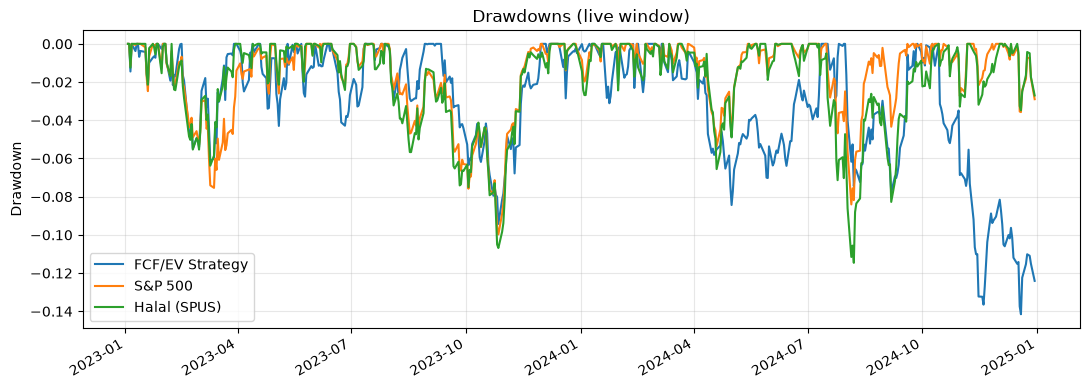

,FCF/EV Strategy,S&P 500,Halal (SPUS)
Year,,,
2023,53.14%,26.18%,34.20%
2024,2.71%,25.34%,27.67%


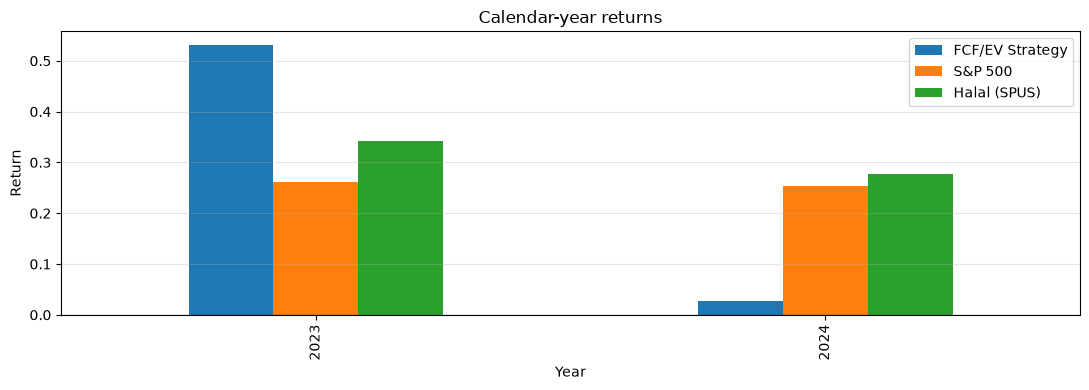

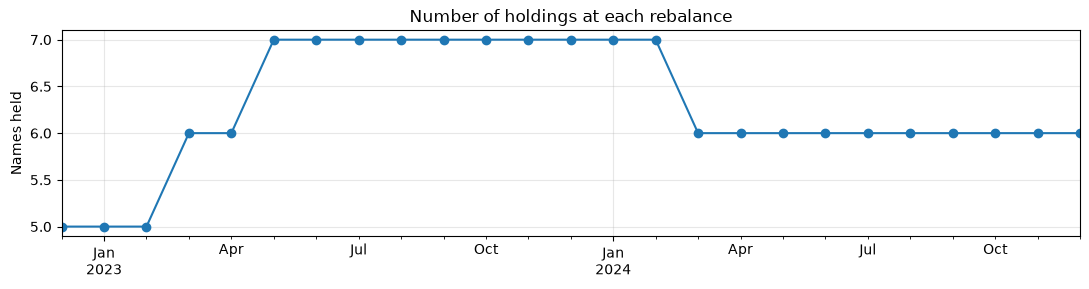

Holdings: min=5  median=6  max=7


In [ ]:
from pathlib import Path

fig_dir = Path.cwd() / "figures"
if not (Path.cwd() / "code.ipynb").exists():
    fig_dir = Path.cwd() / "Research" / "papers" / "01-fcf-ev" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Drawdowns from running peaks (live window)
equity_live = (1 + main_panel).cumprod()
drawdowns = equity_live / equity_live.cummax() - 1
drawdowns.plot(figsize=(11, 4), title="Drawdowns (live window)")
plt.ylabel("Drawdown")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "drawdowns.png", dpi=140)
plt.show()

# Calendar-year returns
yearly = (1 + main_panel).resample("YE").prod() - 1
yearly.index = yearly.index.year
yearly.index.name = "Year"
display(yearly.style.format("{:.2%}").set_caption("Calendar-year returns (live window)"))

yearly.plot(kind="bar", figsize=(11, 4), title="Calendar-year returns")
plt.ylabel("Return")
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "calendar-year-returns.png", dpi=140)
plt.show()

# How many names were held each month
if selections.empty:
    print("No holdings log — skip concentration chart.")
else:
    holdings_count = (
        selections.groupby("as_of")["symbol"]
        .nunique()
        .sort_index()
    )
    holdings_count.index = pd.to_datetime(holdings_count.index)
    holdings_count.plot(
        figsize=(11, 3),
        marker="o",
        title="Number of holdings at each rebalance",
    )
    plt.ylabel("Names held")
    plt.xlabel("")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "holdings-count.png", dpi=140)
    plt.show()
    print(
        f"Holdings: min={int(holdings_count.min())}  "
        f"median={holdings_count.median():.0f}  "
        f"max={int(holdings_count.max())}"
    )

## Step 9 — Does cheaper cash-flow actually earn more?

Buying the top fifth only shows the long book versus the market. A factor paper also needs the **other side**: split every Halal-compliant name into five buckets by FCF/EV.

- **Q1** = highest FCF/EV (cheapest cash-flow, what we buy)
- **Q5** = lowest FCF/EV (most expensive cash-flow)

If FCF/EV is a real signal, Q1 should beat Q5. If they look the same, the blue line in Step 7 may just be a lucky sector mix, not the factor.

,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Strategy,,,,,,
Q1,23.58%,16.28%,1.26,1.88,-14.15%,1.67
Q2,24.49%,17.48%,1.23,2.00,-17.36%,1.41
Q3,15.03%,17.35%,0.78,1.13,-12.04%,1.25
Q4,11.47%,16.07%,0.63,0.94,-17.93%,0.64
Q5,31.81%,24.23%,1.18,1.82,-17.86%,1.78


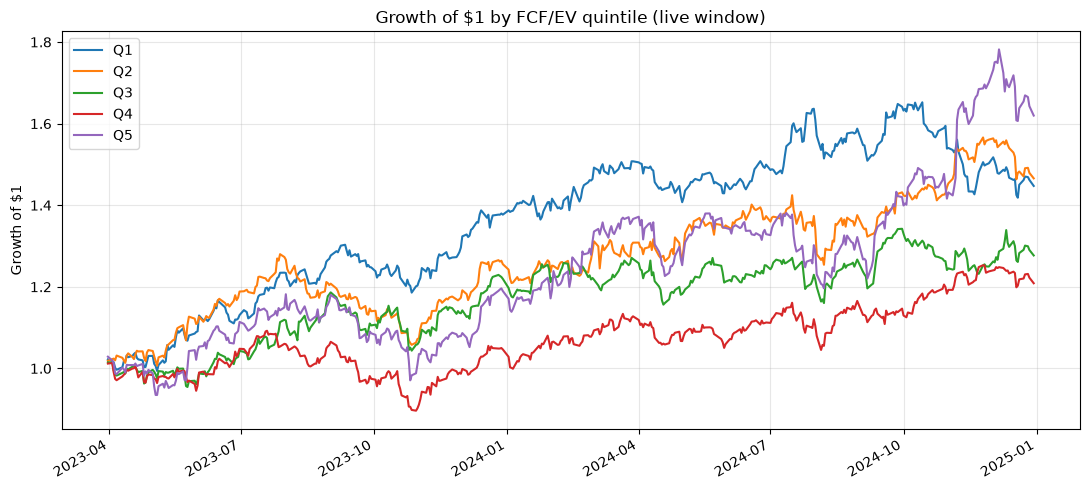

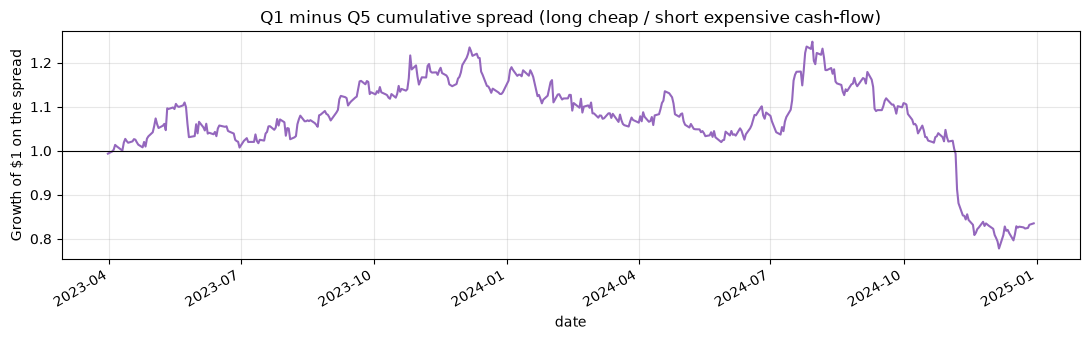

Q1−Q5 annualized spread: -8.05%  ·  hit rate (Q1 beats Q5 that day): 47.0%


In [ ]:
def equal_weight_returns(
    picks_by_date: dict[date, list[str]],
    daily_returns: pd.DataFrame,
) -> pd.Series:
    """Build a daily equal-weight book from a {rebalance_date: tickers} map."""
    rebal = sorted(picks_by_date)
    active: list[str] = []
    last: date | None = None
    live = False
    rows: list[float] = []

    for dt in daily_returns.index:
        prior = [d for d in rebal if pd.Timestamp(d) <= dt]
        if prior and prior[-1] != last:
            active = picks_by_date.get(prior[-1], [])
            last = prior[-1]
            if active:
                live = True
        if not live:
            rows.append(np.nan)
            continue
        held = [s for s in active if s in daily_returns.columns]
        if not held:
            rows.append(0.0)
            continue
        day_ret = daily_returns.loc[dt, held].mean(skipna=True)
        rows.append(0.0 if pd.isna(day_ret) else float(day_ret))

    return pd.Series(rows, index=pd.to_datetime(daily_returns.index), name="return")


N_Q = 5
scored_panel = attach_latest_fcf(metrics, fcf_history)
screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
price_panel = (
    prices[prices["symbol"].isin(eligible_universe)]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
stock_returns = price_panel.pct_change(fill_method=None)

quantile_picks: dict[int, dict[date, list[str]]] = {q: {} for q in range(1, N_Q + 1)}
for as_of in rebalance_dates:
    ranked = select_top_fcf_ev(
        scored_panel,
        as_of=as_of,
        top_quantile=1.0,
        min_holdings=1,
        screener=screener,
    )
    n = len(ranked)
    if n < N_Q * 2:
        continue
    edges = np.linspace(0, n, N_Q + 1).astype(int)
    for q in range(N_Q):
        chunk = ranked.iloc[edges[q] : edges[q + 1]]
        quantile_picks[q + 1][as_of] = chunk["symbol"].tolist()

quantile_returns = pd.DataFrame(
    {
        f"Q{q}": equal_weight_returns(quantile_picks[q], stock_returns)
        for q in range(1, N_Q + 1)
    }
)
quantile_live = quantile_returns.reindex(main_panel.index).dropna(how="any")

q_rows = [
    calc_performance_stats(quantile_live[col], col)
    for col in quantile_live.columns
]
q_stats = pd.DataFrame(q_rows).set_index("Strategy")
display(q_stats.style.format(formatters).set_caption(
    "FCF/EV quintiles inside the Halal-compliant universe  ·  Q1 = cheapest cash-flow"
))

q_equity = (1 + quantile_live).cumprod()
q_equity.plot(figsize=(11, 5), title="Growth of $1 by FCF/EV quintile (live window)")
plt.ylabel("Growth of $1")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "quintile-growth.png", dpi=140)
plt.show()

if {"Q1", "Q5"}.issubset(quantile_live.columns):
    spread = quantile_live["Q1"] - quantile_live["Q5"]
    spread_equity = (1 + spread).cumprod()
    spread_equity.plot(
        figsize=(11, 3.5),
        color="tab:purple",
        title="Q1 minus Q5 cumulative spread (long cheap / short expensive cash-flow)",
    )
    plt.axhline(1.0, color="black", linewidth=0.8)
    plt.ylabel("Growth of $1 on the spread")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "quintile-spread.png", dpi=140)
    plt.show()
    print(
        f"Q1−Q5 annualized spread: {spread.mean() * 252:.2%}  ·  "
        f"hit rate (Q1 beats Q5 that day): {(quantile_live['Q1'] > quantile_live['Q5']).mean():.1%}"
    )

## Step 10 — Attribution: stock picking or a hidden sector bet?

White-paper section 4 asks whether the result is really FCF/EV, or just “we accidentally owned more of a hot sector.”

- **Beta** — if the market moves 1%, how much does our book tend to move? Around 1 means market-like; below 1 means it usually moves less.
- **Alpha** — leftover return after subtracting that market-related piece. Positive alpha is the part that is *not* “we just rode the S&P 500.”
- **Tracking error** — how differently we wiggle versus the benchmark. High tracking error means the book does not behave like the ETF.
- **Sector mix** — average industry weights of our holdings versus an equal-weight Halal S&P basket. Big gaps here can explain a lot of the blue vs green gap.

,Alpha (ann.),Beta,R²,Tracking error,Information ratio
Benchmark,,,,,
S&P 500,2.40%,0.90,0.49,11.86%,0.02
Halal (SPUS),3.96%,0.69,0.40,13.60%,-0.30


,FCF/EV (avg. month),Halal universe (equal weight),Delta
technology,32.4%,22.4%,9.9%
healthcare,22.6%,14.3%,8.3%
consumer cyclical,20.5%,14.3%,6.3%
basic materials,17.1%,4.1%,13.1%
communication services,16.7%,8.2%,8.5%
industrials,16.7%,8.2%,8.5%
energy,16.7%,4.1%,12.6%
consumer defensive,15.9%,2.0%,13.8%
utilities,0.0%,12.2%,-12.2%
financial services,0.0%,6.1%,-6.1%


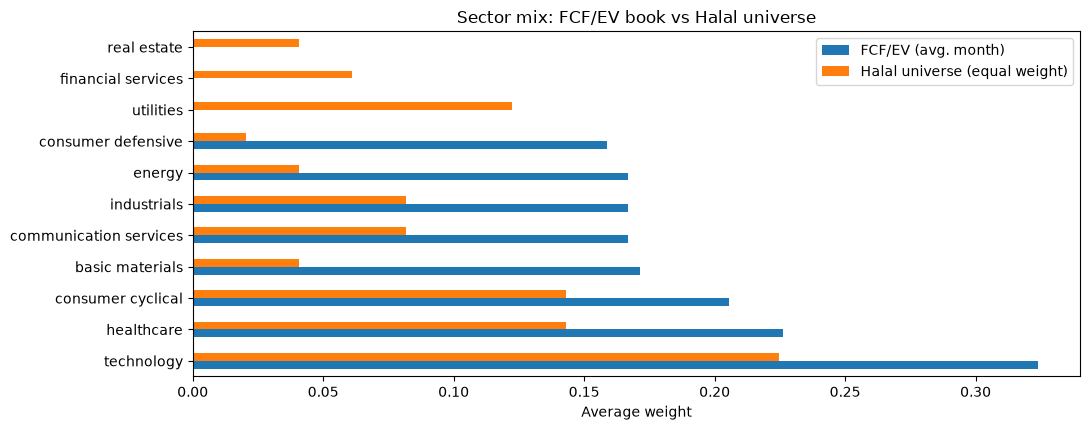

In [ ]:
def capm_attribution(strategy: pd.Series, benchmark: pd.Series, rf: float = RISK_FREE_RATE) -> dict:
    """Alpha, beta, R², tracking error vs one benchmark (daily, then annualized)."""
    aligned = pd.concat([strategy, benchmark], axis=1, keys=["y", "x"]).dropna()
    rf_d = rf / 252
    ye = aligned["y"] - rf_d
    xe = aligned["x"] - rf_d
    var_x = xe.var()
    beta = float(ye.cov(xe) / var_x) if var_x > 0 else np.nan
    alpha_d = float(ye.mean() - beta * xe.mean()) if pd.notna(beta) else np.nan
    resid = ye - alpha_d - beta * xe
    r2 = 1 - resid.var() / ye.var() if ye.var() > 0 else np.nan
    excess = aligned["y"] - aligned["x"]
    te = float(excess.std() * np.sqrt(252))
    ir = float(excess.mean() * 252 / te) if te > 0 else np.nan
    return {
        "Alpha (ann.)": alpha_d * 252,
        "Beta": beta,
        "R²": r2,
        "Tracking error": te,
        "Information ratio": ir,
    }


attr_rows = []
for bench_name in BENCHMARKS:
    row = capm_attribution(main_panel["FCF/EV Strategy"], main_panel[bench_name])
    row["Benchmark"] = bench_name
    attr_rows.append(row)
attr = pd.DataFrame(attr_rows).set_index("Benchmark")
display(
    attr.style.format({
        "Alpha (ann.)": "{:.2%}",
        "Beta": "{:.2f}",
        "R²": "{:.2f}",
        "Tracking error": "{:.2%}",
        "Information ratio": "{:.2f}",
    }).set_caption("FCF/EV strategy vs each benchmark (live window)")
)

if "activity_labels" not in globals():
    _, _, activity_labels = apply_sector_screen(list(eligible_universe))

# Activity labels from the Step 1 screen (already downloaded — no extra API loop)
gics = {s: activity_labels.get(s, "Unclassified") for s in eligible_universe}
gics.update({s: activity_labels.get(s, "Unclassified") for s in selections["symbol"].unique()})

universe_w = (
    pd.Series({s: activity_labels.get(s, "Unclassified") for s in eligible_universe})
    .value_counts(normalize=True)
    .rename("Halal universe (equal weight)")
)

if selections.empty:
    print("No holdings log — skip sector mix.")
else:
    month_weights = []
    for as_of, snap in selections.groupby("as_of"):
        w = 1 / len(snap)
        month_weights.append(
            snap.assign(weight=w)
            .assign(sector=lambda d: d["symbol"].map(gics).fillna("Unclassified"))
            .groupby("sector")["weight"]
            .sum()
        )
    strat_w = pd.concat(month_weights, axis=1).mean(axis=1).rename("FCF/EV (avg. month)")
    sector_mix = pd.concat([strat_w, universe_w], axis=1).fillna(0.0)
    sector_mix["Delta"] = sector_mix["FCF/EV (avg. month)"] - sector_mix["Halal universe (equal weight)"]
    sector_mix = sector_mix.sort_values("FCF/EV (avg. month)", ascending=False)
    display(sector_mix.style.format("{:.1%}").set_caption(
        "Average sector weights  ·  delta = strategy minus Halal universe"
    ))
    sector_mix.drop(columns="Delta").plot(
        kind="barh",
        figsize=(11, max(4, 0.4 * len(sector_mix))),
        title="Sector mix: FCF/EV book vs Halal universe",
    )
    plt.xlabel("Average weight")
    plt.tight_layout()
    plt.savefig(fig_dir / "sector-mix.png", dpi=140)
    plt.show()

## Step 11 — Friction: turnover, trading costs, purification

A paper result that ignores costs is an upper bound. This section asks what is left after three real-world leaks:

1. **Turnover** — each month we sell some names and buy others. High turnover means more trading.
2. **Trading cost** — we subtract `COST_BPS` (default 10 basis points, i.e. 0.10%) on each one-way trade. That is a simple stand-in for commissions + slippage, not a broker quote.
3. **Purification** — for Halal portfolios, a slice of dividend income tied to impure revenue is given away. That is a drag the S&P 500 does not have.

Item,Value
Rebalances with holdings,25
Average names held,6.3
Annualized one-way turnover,241.9%
Assumed cost per one-way trade,10 bps
Estimated annual trading-cost drag,0.24%
CAGR gross of trading costs,25.59%
CAGR net of trading costs,25.22%


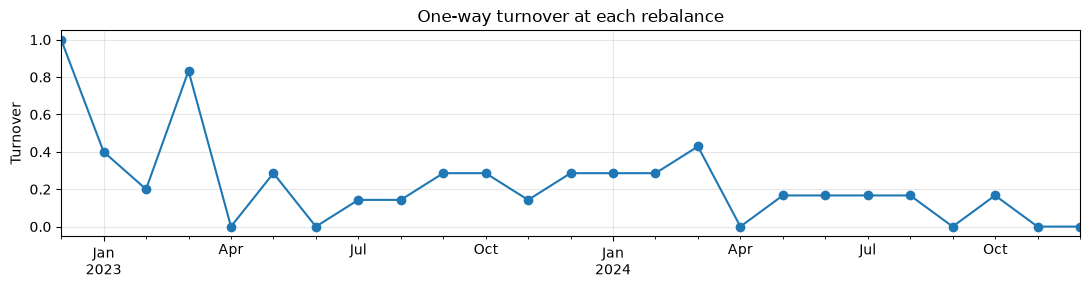

Fetching dividend purification for names the strategy held …
Dividend events while held: 29  ·  annualized purification drag ≈ 0.01%


,symbol,ex_date,dividend,impure_ratio,purification_amount
0,AAPL,2023-02-10 00:00:00,0.230,0.72%,0.0016
1,AAPL,2023-05-12 00:00:00,0.240,0.72%,0.0017
2,AAPL,2023-08-11 00:00:00,0.240,0.72%,0.0017
3,AAPL,2023-11-10 00:00:00,0.240,0.72%,0.0017
4,AAPL,2024-02-09 00:00:00,0.240,0.98%,0.0023
5,AAPL,2024-05-10 00:00:00,0.250,0.98%,0.0024
6,AAPL,2024-08-12 00:00:00,0.250,0.98%,0.0024
7,AAPL,2024-11-08 00:00:00,0.250,0.98%,0.0024
8,ABBV,2023-01-12 00:00:00,1.480,—,—
9,ABBV,2023-04-13 00:00:00,1.480,0.32%,0.0047


In [ ]:
def one_way_turnover(old: set[str], new: set[str]) -> float:
    """Half L1 distance between two equal-weight books (0 = no trades, 1 = full replace)."""
    if not new:
        return 0.0
    if not old:
        return 1.0
    names = old | new
    l1 = sum(
        abs((1 / len(new) if s in new else 0.0) - (1 / len(old) if s in old else 0.0))
        for s in names
    )
    return 0.5 * l1


from pathlib import Path

if "COST_BPS" not in globals():
    COST_BPS = 10

if selections.empty:
    raise RuntimeError("No holdings log — re-run the backtest cell first.")

if "price_panel" not in globals():
    price_panel = (
        prices[prices["symbol"].isin(eligible_universe)]
        .pivot(index="date", columns="symbol", values="adj_close")
        .sort_index()
        .ffill()
    )
if "fig_dir" not in globals():
    fig_dir = Path.cwd() / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

rebal_order = sorted(selections["as_of"].unique())
turnover_rows = []
prev: set[str] = set()
for as_of in rebal_order:
    curr = set(selections.loc[selections["as_of"] == as_of, "symbol"])
    turnover_rows.append({"as_of": pd.Timestamp(as_of), "one_way": one_way_turnover(prev, curr), "n": len(curr)})
    prev = curr

turnover = pd.DataFrame(turnover_rows).set_index("as_of")
months = max(len(turnover) - 1, 1)
annual_turnover = turnover["one_way"].iloc[1:].sum() * (12 / months) if len(turnover) > 1 else np.nan
cost_drag_ann = annual_turnover * COST_BPS / 10_000

cost_on_day = pd.Series(0.0, index=main_panel.index)
for as_of, row in turnover.iterrows():
    hit = main_panel.index[main_panel.index >= as_of]
    if len(hit):
        cost_on_day.loc[hit[0]] += float(row["one_way"]) * COST_BPS / 10_000

net_returns = main_panel["FCF/EV Strategy"] - cost_on_day
net_stats = calc_performance_stats(net_returns, f"FCF/EV net of {COST_BPS} bps")
gross_cagr = calc_performance_stats(main_panel["FCF/EV Strategy"], "FCF/EV Strategy")["CAGR"]

friction = pd.DataFrame(
    {
        "Item": [
            "Rebalances with holdings",
            "Average names held",
            "Annualized one-way turnover",
            f"Assumed cost per one-way trade",
            "Estimated annual trading-cost drag",
            "CAGR gross of trading costs",
            "CAGR net of trading costs",
        ],
        "Value": [
            f"{len(turnover)}",
            f"{turnover['n'].mean():.1f}",
            f"{annual_turnover:.1%}",
            f"{COST_BPS} bps",
            f"{cost_drag_ann:.2%}",
            f"{gross_cagr:.2%}",
            f"{net_stats['CAGR']:.2%}",
        ],
    }
)
display(friction.style.hide(axis="index"))

turnover["one_way"].plot(figsize=(11, 3), marker="o", title="One-way turnover at each rebalance")
plt.ylabel("Turnover")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "turnover.png", dpi=140)
plt.show()

# Purification drag on dividends received while a name was held
print("Fetching dividend purification for names the strategy held …")
held_symbols = sorted(selections["symbol"].unique())
try:
    purified = hq.purify_dividends(
        held_symbols,
        start=str(main_panel.index.min().date()),
        end=END,
    )
except Exception as exc:
    purified = pd.DataFrame()
    print(f"Purification lookup failed ({exc}). Skipping drag estimate.")

if purified.empty:
    print("No purification rows returned. Report this as a data gap in the paper, not as 0% drag.")
else:
    held_flags = []
    for as_of, snap in selections.groupby("as_of"):
        held_flags.append(pd.DataFrame({"as_of": pd.Timestamp(as_of), "symbol": snap["symbol"].tolist()}))
    held_log = pd.concat(held_flags, ignore_index=True)

    purified = purified.copy()
    purified["ex_date"] = pd.to_datetime(purified["ex_date"])
    px = price_panel.copy()
    px.index = pd.to_datetime(px.index)

    drag_rows = []
    for _, div in purified.iterrows():
        symbol = div["symbol"]
        ex = div["ex_date"]
        prior_rebal = held_log.loc[held_log["as_of"] <= ex]
        if prior_rebal.empty:
            continue
        last_asof = prior_rebal["as_of"].max()
        that_book = set(held_log.loc[held_log["as_of"] == last_asof, "symbol"])
        if symbol not in that_book:
            continue
        if symbol not in px.columns:
            continue
        hist = px.loc[:ex, symbol].dropna()
        if hist.empty or hist.iloc[-1] <= 0:
            continue
        weight = 1 / len(that_book)
        amount = div.get("purification_amount")
        if pd.isna(amount):
            continue
        drag_rows.append(float(amount) / float(hist.iloc[-1]) * weight)

    years = len(main_panel) / 252
    purify_drag = (sum(drag_rows) / years) if years > 0 else np.nan
    print(
        f"Dividend events while held: {len(drag_rows)}  ·  "
        f"annualized purification drag ≈ {purify_drag:.2%}"
    )
    display(
        purified[["symbol", "ex_date", "dividend", "impure_ratio", "purification_amount"]]
        .head(12)
        .style.format({"dividend": "{:.3f}", "impure_ratio": "{:.2%}", "purification_amount": "{:.4f}"}, na_rep="—")
        .set_caption("Sample purified dividends (all held names, not only ex-dates while held)")
    )

In [19]:
purified['symbol'].value_counts()

symbol
AAPL    8
ABBV    8
ABT     8
ACN     8
ADI     8
ADM     8
ALB     8
ALLE    8
AMAT    8
AMGN    8
AOS     8
BDX     8
BKR     8
MMM     8
APD     7
Name: count, dtype: int64

### Notes on methodology

- **Point-in-time:** `halalquant.get_financial_metrics(..., freq="ME")` uses SEC `filed_date` (or report date + 90 days for non-US filers) so rebalance decisions never use future filings.
- **FCF source:** Free cash flow comes from yfinance annual cash-flow statements with the same 90-day publication lag. This is a pragmatic proxy until cash-flow tags are added to `halalquant`. Yahoo typically only stores a few annual periods, so the book may go live later than `START`.
- **AAOIFI filter:** Sector exclusions run once up front; debt / cash / receivables screens re-run at every rebalance via `AAOIFIScreener`.
- **Selection:** Equal-weight the top `TOP_QUANTILE` (default 20%) of Halal-compliant names with valid FCF/EV. A month is skipped if fewer than `MIN_HOLDINGS` names survive.
- **Live-window stats:** Days before the first real holdings are missing, not 0%. CAGR, Sharpe, drawdown, and the growth chart all start when the strategy is invested. Benchmarks are sliced to that same window.
- **Quintiles:** Q1–Q5 split the same Halal-compliant scored universe. Q1 is cheap cash-flow (near the live book); Q5 is expensive cash-flow.
- **Attribution:** Alpha, beta, and tracking error are vs SPY and SPUS. Sector mix uses Step 1 activity labels versus an equal-weight Halal S&P basket, not official ETF GICS weights.
- **Friction:** Turnover is half the L1 weight change between monthly books. Trading-cost drag applies `COST_BPS` on each one-way turn. Purification uses `halalquant.purify_dividends` on names that appeared in the book; missing income data is a gap, not a 0% drag.
- **Robustness overlay:** `FCF/EV (drop high vol)` keeps the same FCF/EV ranks, then drops the highest-volatility fifth of those picks. If the result only looks good after this cut, the edge is not coming from FCF/EV alone.
- **Benchmarks:** `SPY` proxies the S&P 500; `SPUS` proxies a Halal-screened US large-cap index. Swap tickers in `BENCHMARKS` if you prefer DJIM-tracking products.
- **Runtime:** `FAST_MODE = False` runs the full S&P 500 (~15–45 min depending on network). Steps 8–11 reuse that download. Figures save to `Research/papers/01-fcf-ev/figures/`.
- **White-paper map:** Step 7 → section 3; Steps 8–9 → section 3 extras; Step 10 → section 4; Step 11 → section 5. Hypothesis and strategy rules (sections 1–2) are written in the paper, not computed here.